In [14]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [15]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [16]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_full = torchvision.datasets.EMNIST(
    root="./data", train=True,download=True,transform=transform,split="balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False,download=True,transform=transform,split="balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [18]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.15
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


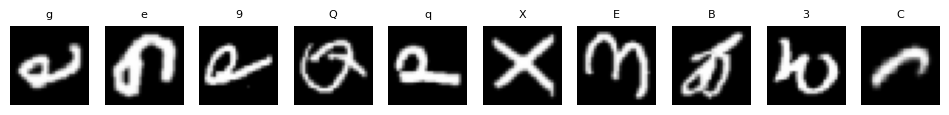

In [19]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()
show_images(test_loader,10)

In [20]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [21]:
def train_one_epoch(model,loader,optimizer,criterion,device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x,y in loader:
        x = x.to(device,non_blocking=True)
        y = y.to(device,non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits,y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits,y)
        n_batches +=1

    return total_loss/n_batches, total_acc/n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [22]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1773, acc=0.6577 | val loss=0.8015, acc=0.7503
epoch 02/20 | train loss=0.6861, acc=0.7801 | val loss=0.6516, acc=0.7907
epoch 03/20 | train loss=0.5779, acc=0.8090 | val loss=0.6129, acc=0.7933
epoch 04/20 | train loss=0.5253, acc=0.8228 | val loss=0.5812, acc=0.8125
epoch 05/20 | train loss=0.4883, acc=0.8320 | val loss=0.5341, acc=0.8288
epoch 06/20 | train loss=0.4592, acc=0.8413 | val loss=0.5318, acc=0.8252
epoch 07/20 | train loss=0.4388, acc=0.8461 | val loss=0.5303, acc=0.8297
epoch 08/20 | train loss=0.4213, acc=0.8509 | val loss=0.5248, acc=0.8295
epoch 09/20 | train loss=0.4035, acc=0.8559 | val loss=0.5510, acc=0.8263
epoch 10/20 | train loss=0.3890, acc=0.8595 | val loss=0.5573, acc=0.8205
epoch 11/20 | train loss=0.3775, acc=0.8624 | val loss=0.5230, acc=0.8324
epoch 12/20 | train loss=0.3661, acc=0.8651 | val loss=0.5511, acc=0.8237
epoch 13/20 | train loss=0.3569, acc=0.8676 | val loss=0.5522, acc=0.8218
epoch 14/20 | train loss=0.3467, acc=0

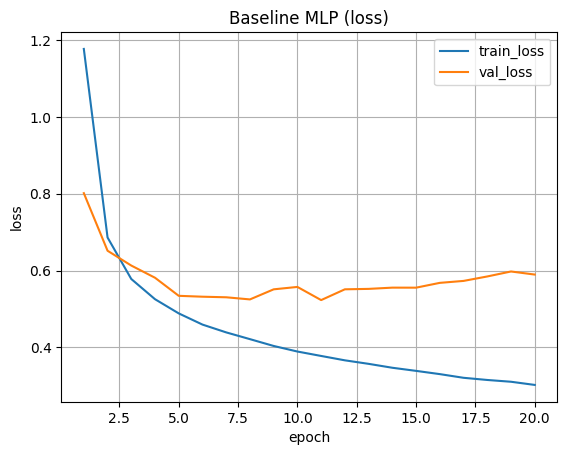

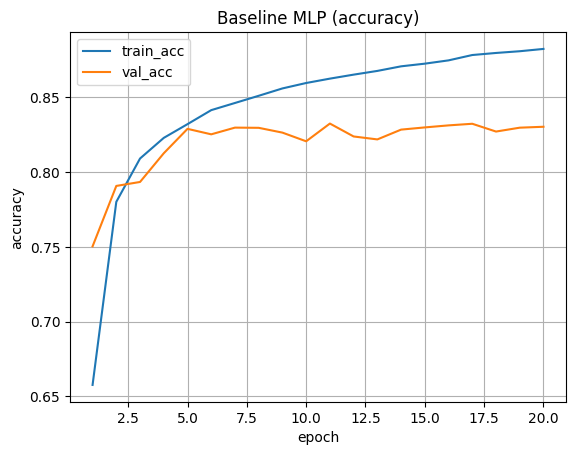

In [23]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [24]:
import pandas as pd

"""resultsE1 = {
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_baseline['train_loss']),
    'best_val_accuracy': max(history_baseline['val_acc']),
    'best_val_loss': min(history_baseline['val_loss'])
}"""



"resultsE1 = {\n    'experiment_id': 'E1',\n    'dataset': 'EMNIST',\n    'seed': 42,\n    'model_summary': 'hidden=[256,128], act=relu, dropout=0.0, bn=False',\n    'optimizer': 'Adam',\n    'lr': 1e-3,\n    'momentum': '',\n    'weight_decay': 0,\n    'epochs_trained': len(history_baseline['train_loss']),\n    'best_val_accuracy': max(history_baseline['val_acc']),\n    'best_val_loss': min(history_baseline['val_loss'])\n}"

epoch 01/20 | train loss=1.5407, acc=0.5509 | val loss=0.8717, acc=0.7301
epoch 02/20 | train loss=1.0534, acc=0.6763 | val loss=0.7467, acc=0.7664
epoch 03/20 | train loss=0.9504, acc=0.7026 | val loss=0.6761, acc=0.7855
epoch 04/20 | train loss=0.9027, acc=0.7172 | val loss=0.6441, acc=0.7912
epoch 05/20 | train loss=0.8677, acc=0.7260 | val loss=0.6192, acc=0.7983
epoch 06/20 | train loss=0.8423, acc=0.7310 | val loss=0.6104, acc=0.7989
epoch 07/20 | train loss=0.8236, acc=0.7357 | val loss=0.5956, acc=0.8055
epoch 08/20 | train loss=0.8070, acc=0.7422 | val loss=0.5950, acc=0.8098
epoch 09/20 | train loss=0.7981, acc=0.7426 | val loss=0.5891, acc=0.8064
epoch 10/20 | train loss=0.7838, acc=0.7468 | val loss=0.5936, acc=0.8028
epoch 11/20 | train loss=0.7814, acc=0.7519 | val loss=0.5642, acc=0.8175
epoch 12/20 | train loss=0.7706, acc=0.7508 | val loss=0.5598, acc=0.8185
epoch 13/20 | train loss=0.7637, acc=0.7524 | val loss=0.5515, acc=0.8164
epoch 14/20 | train loss=0.7526, acc=0

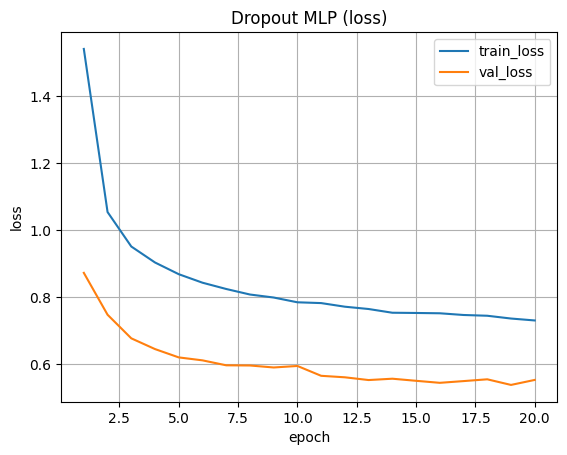

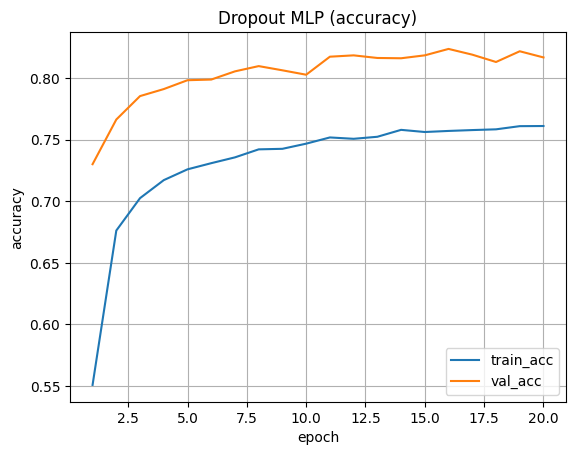

In [25]:
model_dropout = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropout.parameters(), lr=1e-3)

history_dropout = fit(
    model_dropout, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="Dropout MLP")

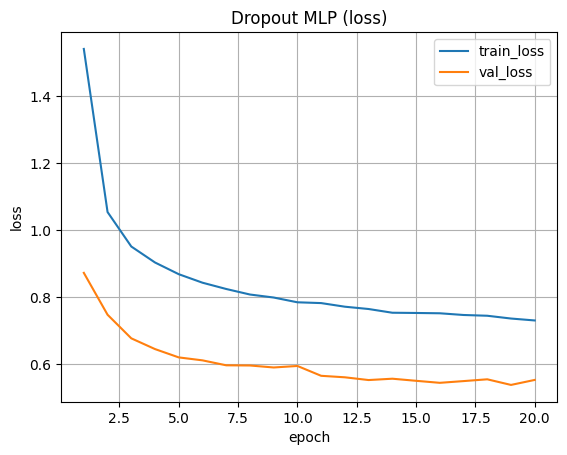

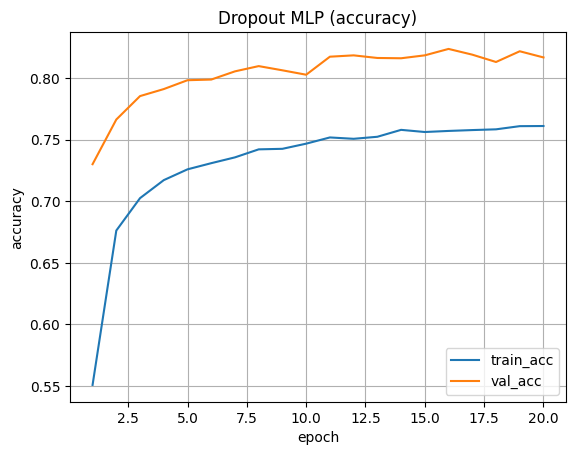

In [26]:
plot_history(history_dropout, title="Dropout MLP")

In [27]:
"""resultsE2 = {
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128], act=relu, dropout=0.3, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_dropout['train_loss']),
    'best_val_accuracy': max(history_dropout['val_acc']),
    'best_val_loss': min(history_dropout['val_loss'])
}"""

"resultsE2 = {\n    'experiment_id': 'E2',\n    'dataset': 'EMNIST',\n    'seed': 42,\n    'model_summary': 'hidden=[256,128], act=relu, dropout=0.3, bn=False',\n    'optimizer': 'Adam',\n    'lr': 1e-3,\n    'momentum': '',\n    'weight_decay': 0,\n    'epochs_trained': len(history_dropout['train_loss']),\n    'best_val_accuracy': max(history_dropout['val_acc']),\n    'best_val_loss': min(history_dropout['val_loss'])\n}"

epoch 01/20 | train loss=0.9010, acc=0.7394 | val loss=0.5991, acc=0.8027
epoch 02/20 | train loss=0.5338, acc=0.8216 | val loss=0.5064, acc=0.8276
epoch 03/20 | train loss=0.4643, acc=0.8403 | val loss=0.4790, acc=0.8396
epoch 04/20 | train loss=0.4220, acc=0.8516 | val loss=0.4548, acc=0.8480
epoch 05/20 | train loss=0.3919, acc=0.8603 | val loss=0.4595, acc=0.8425
epoch 06/20 | train loss=0.3676, acc=0.8676 | val loss=0.4519, acc=0.8487
epoch 07/20 | train loss=0.3479, acc=0.8734 | val loss=0.4427, acc=0.8503
epoch 08/20 | train loss=0.3328, acc=0.8763 | val loss=0.4550, acc=0.8476
epoch 09/20 | train loss=0.3145, acc=0.8828 | val loss=0.4521, acc=0.8465
epoch 10/20 | train loss=0.3044, acc=0.8853 | val loss=0.4490, acc=0.8513
epoch 11/20 | train loss=0.2904, acc=0.8897 | val loss=0.4569, acc=0.8507
epoch 12/20 | train loss=0.2823, acc=0.8923 | val loss=0.4575, acc=0.8499
epoch 13/20 | train loss=0.2707, acc=0.8947 | val loss=0.4709, acc=0.8467
epoch 14/20 | train loss=0.2589, acc=0

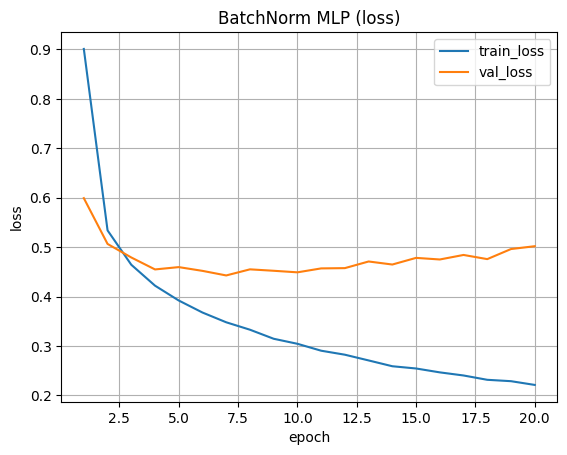

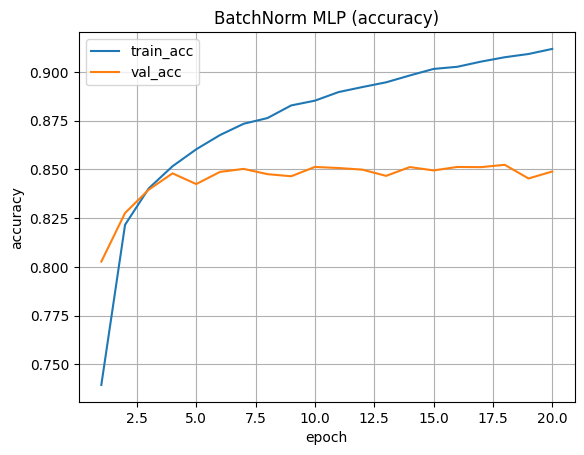

In [28]:
model_batch = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_batch.parameters(), lr=1e-3)

history_batch = fit(
    model_batch, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_batch, title="BatchNorm MLP")

In [29]:
"""resultsE3 = {
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128], act=relu, dropout=0.0, bn=True',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_batch['train_loss']),
    'best_val_accuracy': max(history_batch['val_acc']),
    'best_val_loss': min(history_batch['val_loss'])
}"""

"resultsE3 = {\n    'experiment_id': 'E3',\n    'dataset': 'EMNIST',\n    'seed': 42,\n    'model_summary': 'hidden=[256,128], act=relu, dropout=0.0, bn=True',\n    'optimizer': 'Adam',\n    'lr': 1e-3,\n    'momentum': '',\n    'weight_decay': 0,\n    'epochs_trained': len(history_batch['train_loss']),\n    'best_val_accuracy': max(history_batch['val_acc']),\n    'best_val_loss': min(history_batch['val_loss'])\n}"

In [30]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.9052, acc=0.7388 | val loss=0.5811, acc=0.8140
epoch 02/20 | train loss=0.5309, acc=0.8226 | val loss=0.5049, acc=0.8298
epoch 03/20 | train loss=0.4609, acc=0.8422 | val loss=0.4828, acc=0.8341
epoch 04/20 | train loss=0.4194, acc=0.8532 | val loss=0.4678, acc=0.8435
epoch 05/20 | train loss=0.3908, acc=0.8611 | val loss=0.4588, acc=0.8434
epoch 06/20 | train loss=0.3675, acc=0.8668 | val loss=0.4561, acc=0.8431
epoch 07/20 | train loss=0.3463, acc=0.8736 | val loss=0.4618, acc=0.8458
epoch 08/20 | train loss=0.3305, acc=0.8778 | val loss=0.4543, acc=0.8464
epoch 09/20 | train loss=0.3128, acc=0.8824 | val loss=0.4625, acc=0.8494
epoch 10/20 | train loss=0.3010, acc=0.8860 | val loss=0.4608, acc=0.8486
epoch 11/20 | train loss=0.2879, acc=0.8905 | val loss=0.4556, acc=0.8496
epoch 12/20 | train loss=0.2793, acc=0.8921 | val loss=0.4518, acc=0.8510
epoch 13/20 | train loss=0.2673, acc=0.8965 | val loss=0.4693, acc=0.8493
epoch 14/20 | train loss=0.2611, acc=0

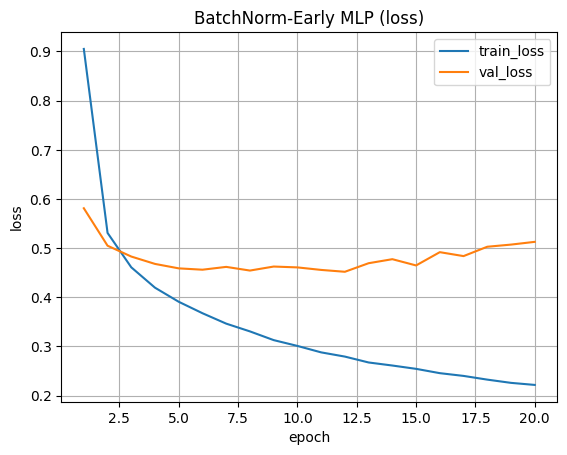

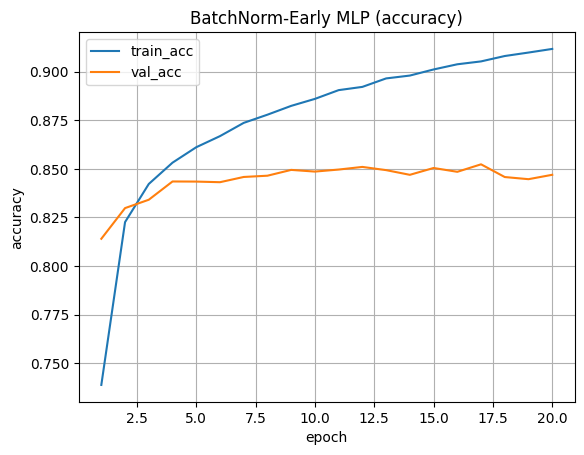

In [31]:
model_batch_early= MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_batch_early.parameters(), lr=1e-3)

early_stopping = EarlyStopping(patience=5, min_delta=0.001)

history_batch_early = fit(
    model_batch_early, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=early_stopping
)

plot_history(history_batch_early, title="BatchNorm-Early MLP")

In [32]:
import torch
torch.save(model_batch_early.state_dict(), 'artifacts/best_model.pt')

In [33]:
import pandas as pd
import os

os.makedirs('artifacts', exist_ok=True)
resultsE1 = {
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=False',  # ✅ пробелы!
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_baseline['train_loss']),
    'best_val_accuracy': max(history_baseline['val_acc']),
    'best_val_loss': min(history_baseline['val_loss'])
}

resultsE2 = {
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.3 bn=False',  # ✅ пробелы!
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_dropout['train_loss']),
    'best_val_accuracy': max(history_dropout['val_acc']),
    'best_val_loss': min(history_dropout['val_loss'])
}

resultsE3 = {
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=True',  # ✅ пробелы!
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_batch['train_loss']),
    'best_val_accuracy': max(history_batch['val_acc']),
    'best_val_loss': min(history_batch['val_loss'])
}

resultsE4 = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=True',  # ✅ пробелы!
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_batch_early['train_loss']),
    'best_val_accuracy': max(history_batch_early['val_acc']),
    'best_val_loss': min(history_batch_early['val_loss'])
}
df1 = pd.DataFrame([resultsE1])
df2 = pd.DataFrame([resultsE2])
df3 = pd.DataFrame([resultsE3])
df4 = pd.DataFrame([resultsE4])

df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

df_all.to_csv('artifacts/runs.csv', index=False)


print(df_all[['experiment_id', 'best_val_accuracy']].to_string())

  experiment_id  best_val_accuracy
0            E1           0.832370
1            E2           0.823762
2            E3           0.852358
3            E4           0.852300


In [34]:
#Финальный тест лучшей модели:
test_loss, test_acc = evaluate(
    model_batch_early,  
    test_loader,
    criterion,
    device
)

print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8431


In [35]:
import json

"""best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model": {
        "hidden_dims": [256, 128],
        "activation": "relu",
        "dropout_p": 0.0,
        "use_batchnorm": True,
        "num_classes": 47
    },
    "training": {
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "early_stopping_patience": 5,
        "epochs_trained": len(history_batch_early['train_loss']),
        "best_val_accuracy": float(max(history_batch_early['val_acc'])),
        "best_val_loss": float(min(history_batch_early['val_loss']))
    }
}"""

best_config = {
    "experiment_id": "E4",
    "hidden_sizes": [256, 128],
    "activation": "relu",
    "dropout_p": 0.0,
    "num_classes": 47,
    "use_batchnorm": True,
    "optimizer": "Adam",
    "lr": 0.001,
    "momentum": 0.0,
    "batch_size": 64,
    "weight_decay": 0.0,
    "dataset": "EMNIST",
    "seed": 42,
    "epochs_trained": len(history_batch_early['train_loss']),
    "best_val_accuracy": float(max(history_batch_early['val_acc'])),
    "best_val_loss": float(min(history_batch_early['val_loss'])),
    "test_loss": test_loss,
    "test_accuracy": test_acc
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

✅ График сохранён: ./artifacts/figures/curves_best.png


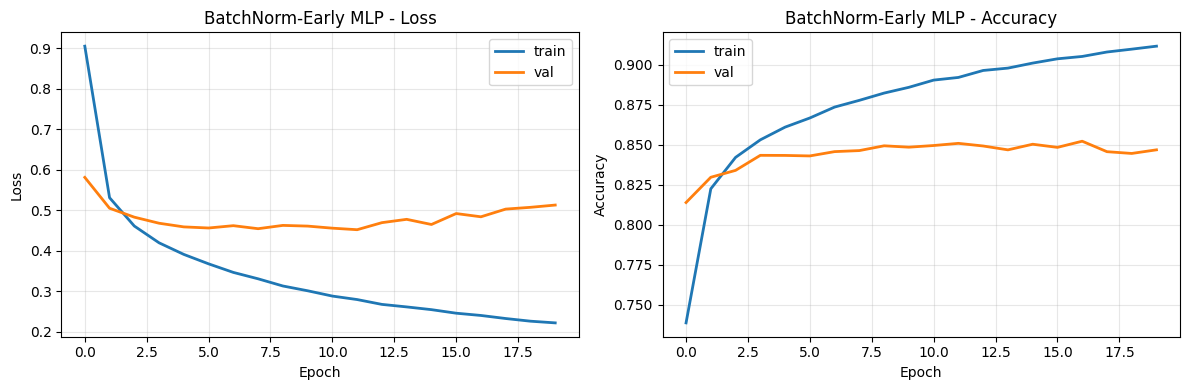

In [36]:
import matplotlib.pyplot as plt

def plot_save_history(history, title, filename=None):
    plt.figure(figsize=(12, 4))
    
    # График Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train', linewidth=2)
    plt.plot(history['val_loss'], label='val', linewidth=2)
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='train', linewidth=2)
    plt.plot(history['val_acc'], label='val', linewidth=2)
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Сохраняем ЕСЛИ указан filename
    if filename:
        # Создаём папку если нужно
        import os
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=100, bbox_inches='tight')
        print(f"✅ График сохранён: {filename}")
    
    # Показываем график
    plt.show()
plot_save_history(history_batch_early,title="BatchNorm-Early MLP", filename="./artifacts/figures/curves_best.png")

In [37]:
def plot_exp(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='train')
    plt.plot(epochs, history['val_loss'], 's-', label='val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'o-', label='train')
    plt.plot(epochs, history['val_acc'], 's-', label='val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [38]:
model_o1 = MLP(
    hidden_dims=(256,128),
    dropout_p=0.0, 
    use_batchnorm=True
).to(device)

optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1) #Большой

history_o1 = fit(
    model_o1, 
    train_loader, 
    val_loader,
    optimizer_o1, 
    criterion, 
    device,
    epochs=5,  # мало эпох, и так понятно будет
    early_stopping=None
)

print("\n ИТОГИ O1:")
print(f"Лучший val_acc: {max(history_o1['val_acc']):.4f}")
print(f"Лучший val_loss: {min(history_o1['val_loss']):.4f}")


epoch 01/5 | train loss=1.1955, acc=0.6406 | val loss=0.9729, acc=0.6947
epoch 02/5 | train loss=0.8755, acc=0.7256 | val loss=0.8145, acc=0.7334
epoch 03/5 | train loss=0.7872, acc=0.7499 | val loss=0.7477, acc=0.7653
epoch 04/5 | train loss=0.7513, acc=0.7618 | val loss=0.7129, acc=0.7834
epoch 05/5 | train loss=0.7185, acc=0.7696 | val loss=0.6673, acc=0.7841

 ИТОГИ O1:
Лучший val_acc: 0.7841
Лучший val_loss: 0.6673


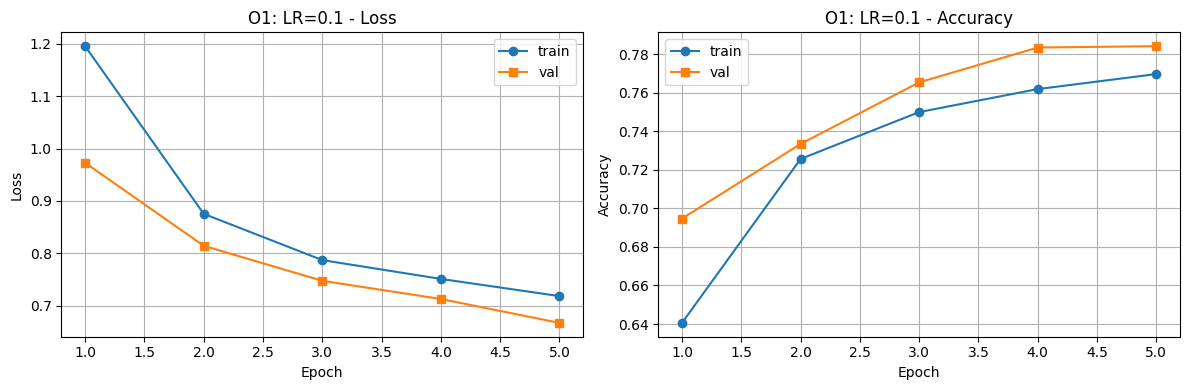

In [39]:
plot_exp(history_o1, "O1: LR=0.1")

O2: LR = 1e-5 (слишком маленький)
epoch 01/5 | train loss=3.3079, acc=0.2449 | val loss=2.8700, acc=0.4455
epoch 02/5 | train loss=2.6369, acc=0.4984 | val loss=2.4146, acc=0.5534
epoch 03/5 | train loss=2.2577, acc=0.5748 | val loss=2.0789, acc=0.6092
epoch 04/5 | train loss=1.9733, acc=0.6162 | val loss=1.8275, acc=0.6394
epoch 05/5 | train loss=1.7445, acc=0.6479 | val loss=1.6291, acc=0.6654
Лучший val_acc: 0.6654


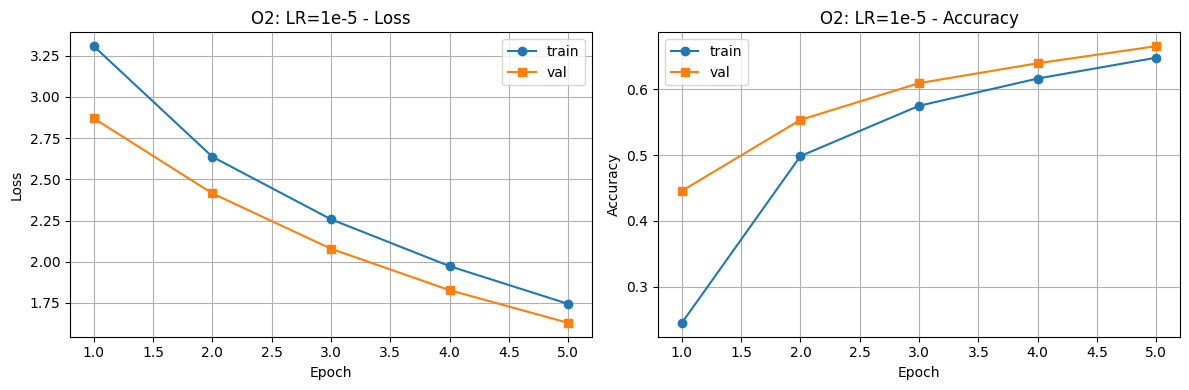

In [40]:
print("O2: LR = 1e-5 (слишком маленький)")

model_o2 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=5)

print(f"Лучший val_acc: {max(history_o2['val_acc']):.4f}")
plot_exp(history_o2, "O2: LR=1e-5")

O3: SGD (lr=0.01, momentum=0.9, weight_decay=1e-4)


epoch 01/8 | train loss=0.9451, acc=0.7269 | val loss=0.6184, acc=0.7999
epoch 02/8 | train loss=0.5612, acc=0.8143 | val loss=0.5249, acc=0.8232
epoch 03/8 | train loss=0.4846, acc=0.8349 | val loss=0.4880, acc=0.8360
epoch 04/8 | train loss=0.4418, acc=0.8470 | val loss=0.4735, acc=0.8416
epoch 05/8 | train loss=0.4111, acc=0.8547 | val loss=0.4683, acc=0.8430
epoch 06/8 | train loss=0.3863, acc=0.8630 | val loss=0.4510, acc=0.8456
epoch 07/8 | train loss=0.3652, acc=0.8702 | val loss=0.4546, acc=0.8461
epoch 08/8 | train loss=0.3497, acc=0.8734 | val loss=0.4530, acc=0.8454
Лучший val_acc: 0.8461


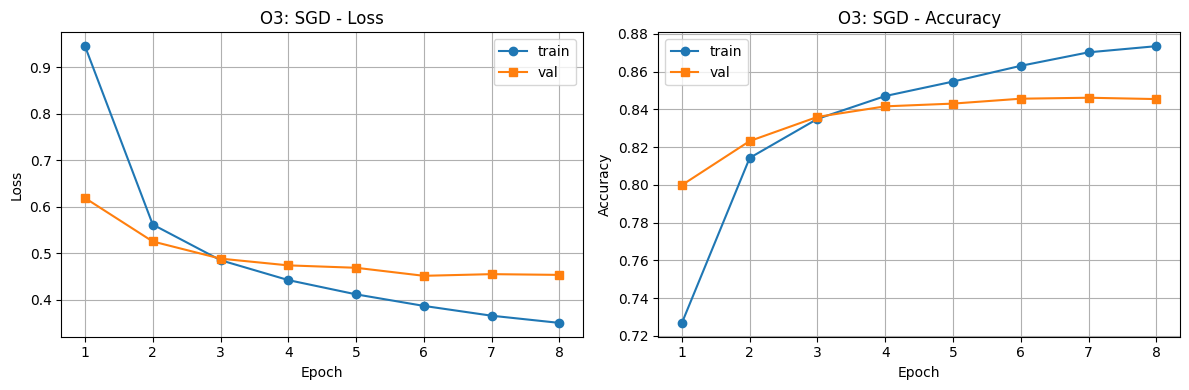

In [41]:
print("O3: SGD (lr=0.01, momentum=0.9, weight_decay=1e-4)")

model_o3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=8)

print(f"Лучший val_acc: {max(history_o3['val_acc']):.4f}")
plot_exp(history_o3, "O3: SGD")

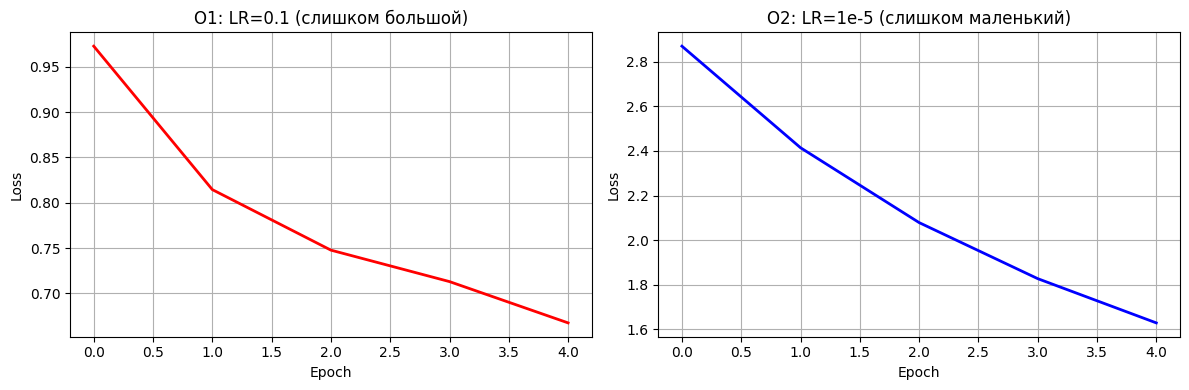

In [42]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o1['val_loss'], 'r-', linewidth=2)
plt.title('O1: LR=0.1 (слишком большой)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o2['val_loss'], 'b-', linewidth=2)
plt.title('O2: LR=1e-5 (слишком маленький)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
os.makedirs('artifacts/figures', exist_ok=True)
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=100, bbox_inches='tight')
plt.show()

In [43]:

resultsO1 = {
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=True',  # как в E4
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_o1['train_loss']),
    'best_val_accuracy': max(history_o1['val_acc']),
    'best_val_loss': min(history_o1['val_loss'])
}

resultsO2 = {
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=True',  # как в E4
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': len(history_o2['train_loss']),
    'best_val_accuracy': max(history_o2['val_acc']),
    'best_val_loss': min(history_o2['val_loss'])
}


resultsO3 = {
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128] act=relu dropout=0.0 bn=True',  # как в E4
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 0.0001,
    'epochs_trained': len(history_o3['train_loss']),
    'best_val_accuracy': max(history_o3['val_acc']),
    'best_val_loss': min(history_o3['val_loss'])
}



In [44]:
import pandas as pd

df_existing = pd.read_csv('artifacts/runs.csv')

df_o = pd.DataFrame([resultsO1, resultsO2, resultsO3])

df_all = pd.concat([df_existing, df_o], ignore_index=True)

df_all.to_csv('artifacts/runs.csv', index=False)